# LangSmith로 Agent 추적하기

## 학습 목표

**에이전트의 도구 호출 루프가 Trace에 어떻게 나타나는지** 읽는 법을 익힌다.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY가 설정되지 않았다."

# 과거 표기(LANGCHAIN_API_KEY)로 저장했어도 같은 키이므로 처리
langsmith_key = os.getenv("LANGCHAIN_API_KEY") or os.getenv("LANGSMITH_API_KEY")
assert langsmith_key, "LANGSMITH_API_KEY가 .env에 설정되지 않았다."

os.environ["LANGSMITH_API_KEY"] = langsmith_key
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "agent-tracing"

print("LangSmith 추적 활성화 -> 프로젝트: agent-tracing")

LangSmith 추적 활성화 -> 프로젝트: agent-tracing


## 1단계: 추적할 에이전트 준비

도구 2개를 가진 표준 에이전트다. 계산기는 eval() 대신 AST 기반 safe_eval을 사용한다.

LLM이 생성한 임의 코드 실행을 차단하는 안전 패턴이다.

In [2]:
import ast
import operator

_ALLOWED_OPS = {
    ast.Add: operator.add, ast.Sub: operator.sub,
    ast.Mult: operator.mul, ast.Div: operator.truediv,
    ast.Pow: operator.pos, ast.Mod: operator.mod,
    ast.USub: operator.neg, ast.UAdd: operator.pos
}

def safe_eval(expression: str):
    """산술 연산자와 숫자만 허용하는 안전한 수식 계산기"""
    node = ast.parse(expression, mode="eval").body

    def _eval(n):
        if isinstance(n, ast.Constant) and isinstance(n.value, (int, float)):
            return n.value
        if isinstance(n, ast.BinOp) and type(n.op) in _ALLOWED_OPS:
            return _ALLOWED_OPS[type(n.op)](_eval(n.left), _eval(n.right))
        if isinstance(n, ast.UnaryOp) and type(n.op) in _ALLOWED_OPS:
            return _ALLOWED_OPS[type(n.op)](_eval(n.operand))
        raise ValueError(f"허용되지 않은 수식입니다: {expression}")

    return _eval(node)

from langchain.agents import create_agent
from langchain.tools import tool

@tool
def calculate(expression: str) -> str:
    """수학 계산을 수행한다."""
    try:
        return str(safe_eval(expression))
    except Exception as e:
        return f"계산 오류: {e}"


@tool
def get_weather(city: str) -> str:
    """도시의 날씨를 조회한다."""
    return f"{city}: 맑음, 22도" # 실습용 시뮬레이션

agent = create_agent(
    model="gpt-4o-mini",
    tools=[calculate, get_weather],
    system_prompt = "당신은 도움이 되는 어시스턴트입니다. 한국어로 답하세요."
)

In [3]:
# 도구 2개를 모두 사용해야 하는 복합 질문 -> 루프가 여러 번 돈다

result = agent.invoke(
    {"messages": [{"role": "user", "content": "서울 날씨 알려주고, 123*456 계산해줘"}]},
    config={"run_name": "복합-쿼리", "tags": ["agent-demo"],
            "metadata": {"query_type": "complex"}}
)
print(result["messages"][-1].content)

서울의 날씨는 맑고, 현재 기온은 22도입니다.  
또한, 123 곱하기 456의 계산 결과는 56,088입니다.


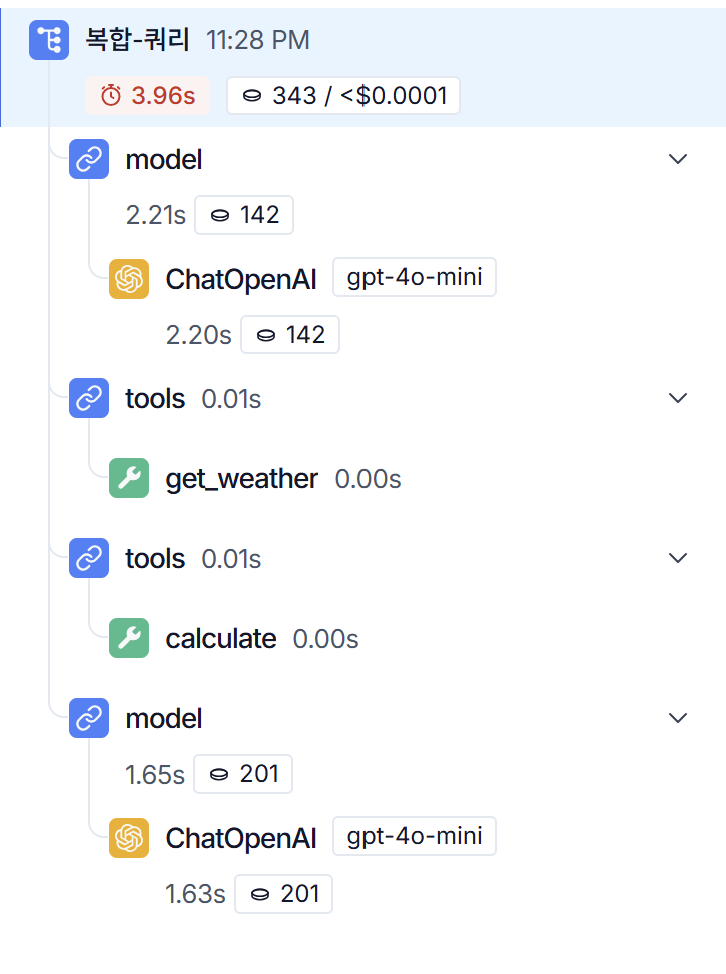

## 2단계: Agent Trace 읽는 법 - 체인과 무엇이 다른가

https://smith.langchain.com 의 프로젝트에서 방금 실행한 `복합-쿼리` Trace를 연다.

체인 Trace가 한 줄로 흐르는 것과 달리, Agent Trace는 **루프 구조**다:

```
agent (root)
├─ model 호출 1  → 출력: tool_calls [get_weather, calculate]   ← 판단
├─ get_weather   → 입력: {"city": "서울"} / 출력: "서울: 맑음..."  ← 행동
├─ calculate     → 입력: {"expression": "123 * 456"} / 출력: "56088"
└─ model 호출 2  → 출력: 최종 답변 텍스트                        ← 종합
```

### 확인 포인트 4가지

1. **루프 횟수**: model 호출이 몇 번인가? (도구 호출 결정 + 최종 답변 = 최소 2회. 병렬 호출이면 2회로 끝나고, 순차 호출이면 더 늘어난다)
2. **도구 입출력**: 각 도구 run을 클릭해 LLM이 만든 인자(`expression`, `city`)가 의도대로인지 확인한다. **도구 호출 실패의 대부분은 인자 생성 오류**이며, 여기서만 정확히 보인다.
3. **단계별 토큰**: model 호출 1과 2의 토큰 수를 비교한다. 도구 결과가 컨텍스트에 쌓이므로 뒤로 갈수록 input 토큰이 늘어난다 — 루프가 길어지면 비용이 가속되는 이유다.
4. **run_name/tags 필터**: 좌측 필터에서 Tags=`agent-demo`로 이 실행만 걸러낸다 (T_P3-7에서 배운 방식 그대로다).

# 3단계: 선택적 추적

전부 추적하면 노이즈가 쌓인다. 특정 실행만 추적하거나 제외하는 방법이다.

In [5]:
from langchain_core.tracers.context import tracing_v2_enabled

# 전역 추적 끄기
os.environ["LANGSMITH_TRACING"] = "false"

result1 = agent.invoke({"messages": [{"role": "user", "content": "1+1 계산해줘."}]})
print("실행 1: 추적 안됨")

# 컨텍스트 매니저 안에서만 추적 (별도 프로젝트로 보낼 수도 있다)
with tracing_v2_enabled(project_name="day5-agent-tracing"):
    result2 = agent.invoke({"messages": [{"role": "user", "content": "2+2 계산해"}]})
    print("실행 2: 추적됨")

# 전역 추적 복원
os.environ["LANGSMITH_TRACING"] = "true"

실행 1: 추적 안됨
실행 2: 추적됨


## 4단계: 대시보드 분석용 실행 쌓기

여러 유형의 실행을 만들어 대시보드에서 비교한다. 스크립트 종료 직전에는 wait_for_all_tracers()로 전송 완료를 보장한다.

(추적은 백그라운드 전송이라 프로세스가 먼저 끝나면 유실될 수 있다.)

In [7]:
from langchain_core.tracers.langchain import wait_for_all_tracers

test_queries = [
    "안녕하세요!", # 도구 없음 
    "100 + 200 계산해줘", # 도구 1개
    "도쿄 날씨 알려줘", # 도구 1개
    "서울 날씨와 50 * 30 계산해줘" # 도구 2개
]

for i, query in enumerate(test_queries, 1):
    agent.invoke(
        {
            "messages": [{"role": "user", "content": query}]
        },
        config = {"run_name": f"test-run-{i}", "tags": ["batch-test"]}
    )
    print(f"test-run-{i} 완료: {query}")

wait_for_all_tracers()
print("모든 트레이스 전송 완료")

test-run-1 완료: 안녕하세요!
test-run-2 완료: 100 + 200 계산해줘
test-run-3 완료: 도쿄 날씨 알려줘
test-run-4 완료: 서울 날씨와 50 * 30 계산해줘
모든 트레이스 전송 완료


## 핵심 정리

### 실습 과제

대시보드에서 Tags=`batch-test`로 필터링한 뒤, 4개 실행의 **model 호출 횟수와 총 토큰**을 표로 정리해본다. "도구 없음 / 1개 / 2개" 질문의 비용 차이가 수치로 드러난다.

### 이 노트북에서 배운 것

1. **Agent Trace 구조**: 판단(model) → 행동(tool) → 종합(model)의 루프. 체인과 달리 model 호출이 여러 번이다.
2. **디버깅 핵심**: 도구 run의 입력(LLM이 생성한 인자)을 보는 것 — 콘솔 출력으로는 안 보이는 정보다.
3. **비용 구조**: 루프가 돌수록 컨텍스트가 누적되어 input 토큰이 가속 증가한다.
4. **선택적 추적**: `tracing_v2_enabled` 컨텍스트 매니저, `wait_for_all_tracers`.